# Bi-orthogonal Embedding — Visual Exploration

Explore the `biort` bi-orthogonal embedding of the *Drosophila* central-complex
ring connectome. Two passes:

1. **EPG only** — the ring-attractor population; ring/angular structure should be cleanest.
2. **Delta7 + EPG** — the full compass circuit; how the two populations separate.

Preprocessing is factored into `scripts/ring_preprocessing.py`; the embedding is
`biort.BiorthEmbedding`. Each panel is rendered interactively (Plotly, hover for
neuron id / instance / cell type / group) and saved as a static PDF to `figures/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

from ring_preprocessing import load_ring_connectome
from biort import BiorthEmbedding

try:
    import umap  # optional
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False

FIG_DIR = os.path.join(os.getcwd(), '..', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def save_pdf(fig, name):
    """Save a matplotlib figure as figures/<name>.pdf."""
    path = os.path.join(FIG_DIR, name + '.pdf')
    fig.savefig(path, bbox_inches='tight')
    print('saved', path)

def show_plotly(fig):
    """Render a Plotly figure, no-op if no renderer is available (headless)."""
    try:
        fig.show()
    except Exception as e:
        print('plotly render skipped:', e)

In [2]:
def fit_embedding(rc, k=8, alpha=0.95, random_state=42):
    """Fit the real (clustering) and complex (modes) embeddings; return a bundle."""
    be = BiorthEmbedding(k=k, alpha=alpha, realify=True, random_state=random_state).fit(rc.A)
    be_c = BiorthEmbedding(k=k, alpha=alpha, realify=False, random_state=random_state).fit(rc.A)
    X = be.get_embedding()                 # (n, 2k) real: [Re(V) | Re(U)]
    U_c, V_c, Lam_c = be_c.get_modes()     # complex left/right modes, slow eigenvalues
    cg = be.get_coarse_graph()
    return dict(
        rc=rc, k=k, be=be, be_c=be_c, X=X, Xf=X[:, :k], Xb=X[:, k:2*k],
        groups=np.asarray(be.groups_), pi=np.asarray(be.pi_),
        U_c=U_c, V_c=V_c, Lam_c=Lam_c, fidelity=cg['fidelity'],
        ctoi=np.array(rc.ctoi), cioi=np.array(rc.cioi), noi=np.array(rc.noi),
        ring=np.asarray(rc.ring_pos), deg_out=rc.A.sum(1), deg_in=rc.A.sum(0),
    )

def _hover(b):
    return [f"{n}<br>{ci}<br>{ct}<br>group {g}"
            for n, ci, ct, g in zip(b['noi'], b['cioi'], b['ctoi'], b['groups'])]

def _type_codes(b):
    types = sorted(set(b['ctoi'].tolist()))
    return types, np.array([types.index(c) for c in b['ctoi']])

In [3]:
def explore_population(rc, tag, k=8, alpha=0.95):
    """Fit the embedding on rc.A and emit the full visual suite (Plotly + PDF)."""
    b = fit_embedding(rc, k=k, alpha=alpha)
    Lam, V_c = b['Lam_c'], b['V_c']
    Xf, Xb, groups = b['Xf'], b['Xb'], b['groups']
    ctoi, ring, hover = b['ctoi'], b['ring'], _hover(b)
    types, tcodes = _type_codes(b)
    print(f"[{tag}] n={rc.n}  k={k}  groups={len(np.unique(groups))}  "
          f"fidelity={b['fidelity']:.4f}")

    # --- Panel 1: slow eigenvalue spectrum (complex plane) -------------------
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(Lam.real, Lam.imag, s=90, edgecolors='k', alpha=.8)
    for i, l in enumerate(Lam):
        ax.annotate(str(i), (l.real, l.imag), fontsize=8, xytext=(3, 3),
                    textcoords='offset points')
    ax.axhline(0, ls='--', c='r', alpha=.3); ax.axvline(0, ls='--', c='r', alpha=.3)
    ax.set_xlabel('Re(λ)  (decay)'); ax.set_ylabel('Im(λ)  (oscillation)')
    ax.set_title(f'[{tag}] slow eigenvalues of L'); ax.grid(alpha=.3)
    n_osc = int((np.abs(Lam.imag) / np.maximum(np.abs(Lam.real), 1e-12) > 0.1).sum())
    print(f"[{tag}] genuinely oscillatory slow modes (|Im|/|Re|>0.1): {n_osc}/{len(Lam)}")
    save_pdf(fig, f'biort_{tag}_spectrum'); plt.show()
    show_plotly(px.scatter(
        x=Lam.real, y=Lam.imag, text=[str(i) for i in range(len(Lam))],
        labels={'x': 'Re(λ)', 'y': 'Im(λ)'}, title=f'[{tag}] slow eigenvalues')
        .update_traces(marker_size=12, textposition='top center'))

    # --- Panel 2: bi-embedding pair grid (forward / backward) ----------------
    fig, axs = plt.subplots(2, 2, figsize=(11, 10))
    for row, (M, lab) in enumerate([(Xf, 'forward V'), (Xb, 'backward U')]):
        sc0 = axs[row, 0].scatter(M[:, 0], M[:, 1], c=tcodes, cmap='tab10', s=45, alpha=.8)
        axs[row, 0].set_title(f'{lab}: mode 1 vs 2 — cell type')
        sc1 = axs[row, 1].scatter(M[:, 0], M[:, 1], c=groups, cmap='tab10', s=45, alpha=.8)
        axs[row, 1].set_title(f'{lab}: mode 1 vs 2 — group')
        for ax in axs[row]:
            ax.set_xlabel('mode 1'); ax.set_ylabel('mode 2'); ax.grid(alpha=.3)
    handles = [plt.Line2D([], [], marker='o', ls='', color=plt.cm.tab10(i / 10), label=t)
               for i, t in enumerate(types)]
    axs[0, 0].legend(handles=handles, fontsize=8, loc='best')
    fig.suptitle(f'[{tag}] bi-embedding pair grid'); fig.tight_layout()
    save_pdf(fig, f'biort_{tag}_pairgrid'); plt.show()
    show_plotly(px.scatter(
        x=Xf[:, 0], y=Xf[:, 1], color=ctoi, hover_name=hover,
        labels={'x': 'forward mode 1', 'y': 'forward mode 2'},
        title=f'[{tag}] forward modes (hover for detail)'))

    # --- Panel 3: ring manifold (adaptive to spectrum) -----------------------
    # If a genuinely oscillatory mode exists, plot its complex plane; otherwise
    # (real spectrum) plot the two leading non-trivial real forward modes, whose
    # near-degenerate eigenvalues act as cos/sin ring harmonics.
    cand = (np.argmax(np.abs(Lam[1:].imag)) + 1) if len(Lam) > 1 else 0
    osc_ratio = np.abs(Lam[cand].imag) / max(np.abs(Lam[cand].real), 1e-12)
    if len(Lam) > 1 and osc_ratio > 0.1:   # genuinely rotating mode (Im comparable to Re)
        xc, yc = V_c[:, cand].real, V_c[:, cand].imag
        xlab, ylab, sub, fname = (f'Re(v_{cand})', f'Im(v_{cand})',
                                  f'complex mode v_{cand}', 'complexmode_ring')
    else:
        xc, yc = Xf[:, 1], Xf[:, 2]
        xlab, ylab, sub, fname = ('forward mode 1', 'forward mode 2',
                                  'forward modes 1 vs 2 (real spectrum)', 'ring_manifold')
    fig, ax = plt.subplots(figsize=(6.8, 6))
    fin = np.isfinite(ring)
    if (~fin).any():
        ax.scatter(xc[~fin], yc[~fin], c='lightgray', s=45, edgecolors='k', label='no ring coord')
    sc = ax.scatter(xc[fin], yc[fin], c=ring[fin], cmap='twilight', s=60, edgecolors='k')
    if fin.any():
        fig.colorbar(sc, ax=ax, label='EPG ring position')
    ax.axhline(0, ls='--', c='r', alpha=.3); ax.axvline(0, ls='--', c='r', alpha=.3)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.set_title(f'[{tag}] ring manifold — {sub}')
    ax.set_aspect('equal'); ax.grid(alpha=.3)
    if (~fin).any():
        ax.legend(fontsize=8)
    save_pdf(fig, f'biort_{tag}_{fname}'); plt.show()
    show_plotly(px.scatter(
        x=xc, y=yc, color=ctoi, hover_name=hover,
        labels={'x': xlab, 'y': ylab}, title=f'[{tag}] ring manifold — {sub}'))

    # --- Panel 4: mode profiles vs ring position (EPG only) ------------------
    if fin.sum() >= 3:
        order = np.argsort(ring[fin])
        rp = ring[fin][order]
        fig, ax = plt.subplots(figsize=(9, 5))
        for j in range(1, min(5, V_c.shape[1])):
            ax.plot(rp, V_c[fin, j].real[order], 'o-', ms=4, label=f'Re(v_{j})')
        ax.set_xlabel('EPG ring position'); ax.set_ylabel('mode coefficient')
        ax.set_title(f'[{tag}] slow-mode profiles along the ring (expect harmonics)')
        ax.legend(fontsize=8); ax.grid(alpha=.3)
        save_pdf(fig, f'biort_{tag}_mode_profiles'); plt.show()
    else:
        print(f'[{tag}] no EPG ring coordinate available — skipping mode profiles')

    # --- Panel 5: forward vs backward role scatter ---------------------------
    fwd = np.linalg.norm(Xf, axis=1); bwd = np.linalg.norm(Xb, axis=1)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for i, t in enumerate(types):
        msk = b['ctoi'] == t
        ax.scatter(fwd[msk], bwd[msk], s=45, alpha=.8, label=t, color=plt.cm.tab10(i / 10))
    lim = max(fwd.max(), bwd.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', alpha=.3)
    ax.set_xlabel('forward participation  ‖V_i‖  (driver-like)')
    ax.set_ylabel('backward participation  ‖U_i‖  (sink-like)')
    ax.set_title(f'[{tag}] forward vs backward role'); ax.legend(fontsize=8); ax.grid(alpha=.3)
    save_pdf(fig, f'biort_{tag}_roles'); plt.show()
    show_plotly(px.scatter(
        x=fwd, y=bwd, color=ctoi, hover_name=hover,
        labels={'x': 'forward ‖V_i‖', 'y': 'backward ‖U_i‖'},
        title=f'[{tag}] forward vs backward role'))

    # --- Panel 6: global 2-D projection of the 2k embedding ------------------
    P = PCA(n_components=2, random_state=0).fit_transform(b['X'])
    method = 'PCA'
    if HAVE_UMAP and rc.n > 15:
        try:
            P = umap.UMAP(n_components=2, random_state=42).fit_transform(b['X']); method = 'UMAP'
        except Exception as e:
            print('UMAP failed, using PCA:', e)
    fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
    axs[0].scatter(P[:, 0], P[:, 1], c=tcodes, cmap='tab10', s=50, alpha=.8)
    axs[0].set_title(f'{method} of bi-embedding — cell type')
    axs[1].scatter(P[:, 0], P[:, 1], c=groups, cmap='tab10', s=50, alpha=.8)
    axs[1].set_title(f'{method} of bi-embedding — group')
    for ax in axs:
        ax.set_xlabel(f'{method} 1'); ax.set_ylabel(f'{method} 2'); ax.grid(alpha=.3)
    fig.suptitle(f'[{tag}] global projection'); fig.tight_layout()
    save_pdf(fig, f'biort_{tag}_projection'); plt.show()
    show_plotly(px.scatter(
        x=P[:, 0], y=P[:, 1], color=ctoi, hover_name=hover,
        labels={'x': f'{method} 1', 'y': f'{method} 2'},
        title=f'[{tag}] {method} projection'))

    # --- Panel 7: cell-type x group structure --------------------------------
    ct = pd.crosstab(pd.Series(b['ctoi'], name='cell type'),
                     pd.Series(groups, name='group'))
    purity = (ct.max(axis=0) / ct.sum(axis=0)).mean()
    fig, ax = plt.subplots(figsize=(1.2 * ct.shape[1] + 3, 0.6 * ct.shape[0] + 2))
    im = ax.imshow(ct.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
    ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, ct.values[i, j], ha='center', va='center',
                    color='w', fontsize=8)
    ax.set_xlabel('group'); ax.set_ylabel('cell type')
    ax.set_title(f'[{tag}] cell type x group  (mean purity {purity:.2f})')
    fig.colorbar(im, ax=ax, label='count')
    save_pdf(fig, f'biort_{tag}_contingency'); plt.show()
    print(ct)
    return b

## Pass 1 — EPG only

The EPG population alone (46 neurons). Loaded with the L/R-wedge **spatial** ring
ordering so the ring coordinate is well defined for every node.

[epg] n=46  k=8  groups=8  fidelity=3.3445
[epg] genuinely oscillatory slow modes (|Im|/|Re|>0.1): 0/8
saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_spectrum.pdf


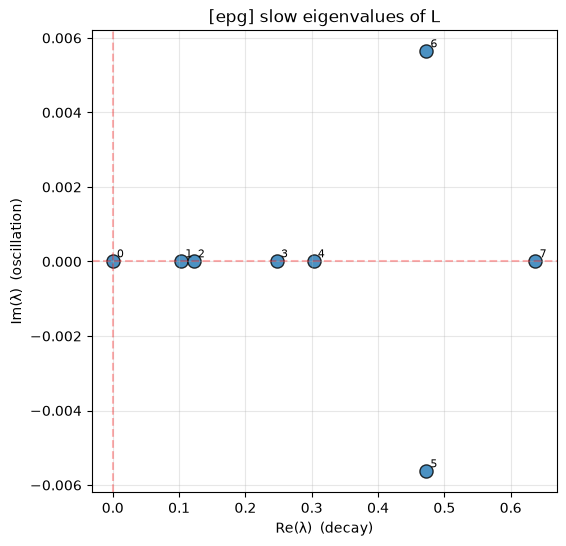

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_pairgrid.pdf


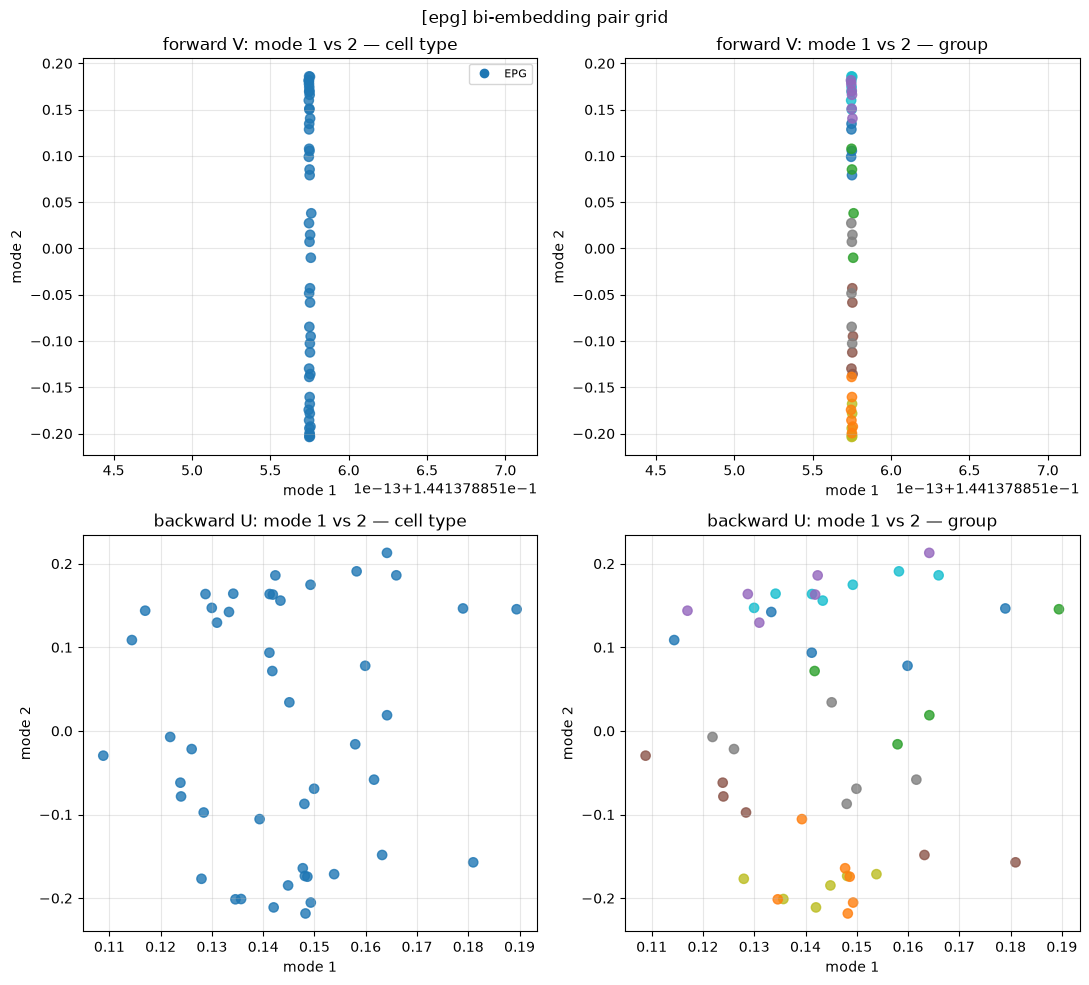

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_ring_manifold.pdf


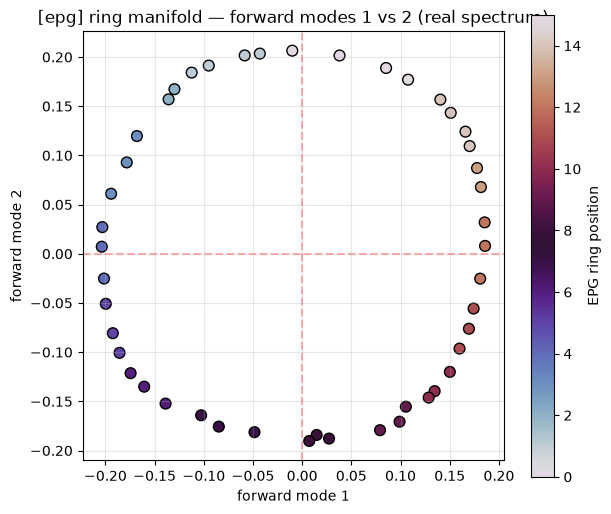

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_mode_profiles.pdf


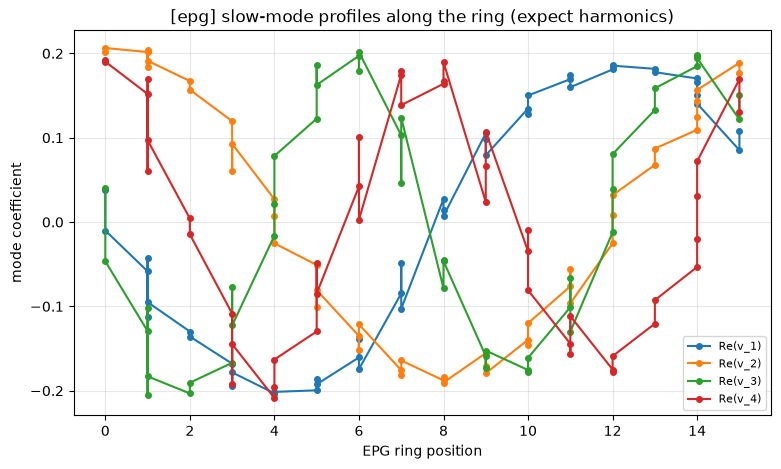

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_roles.pdf


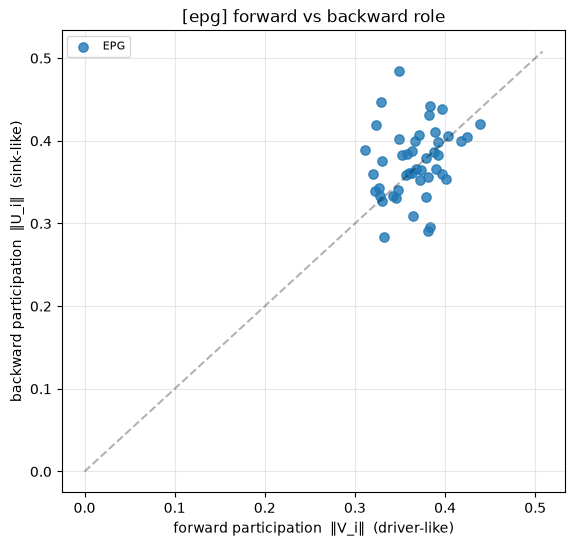

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_projection.pdf


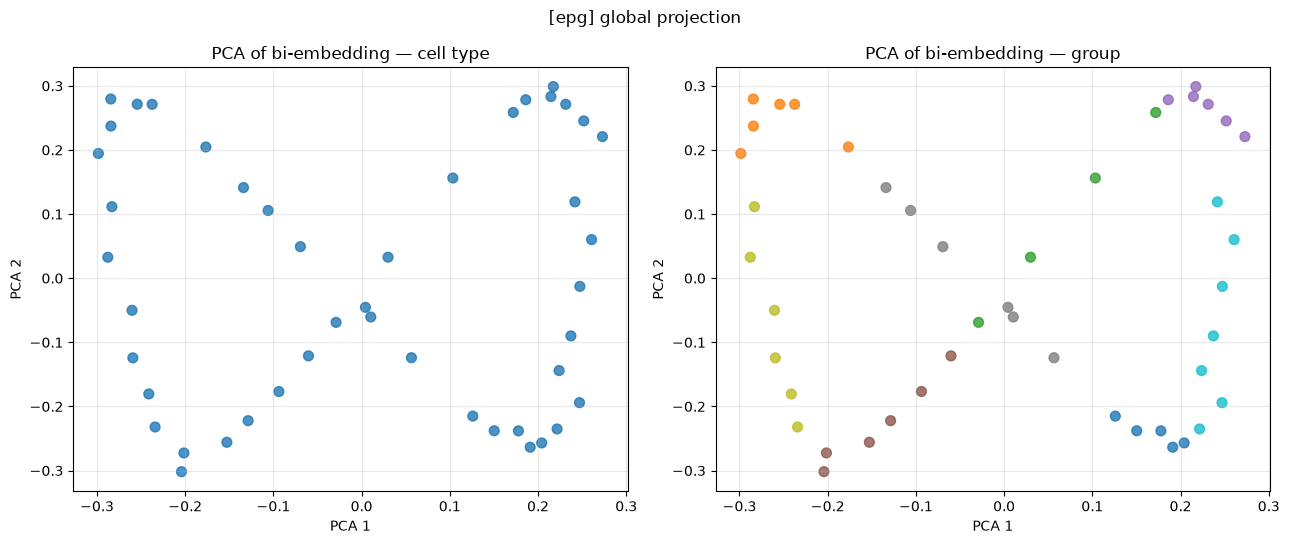

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_epg_contingency.pdf


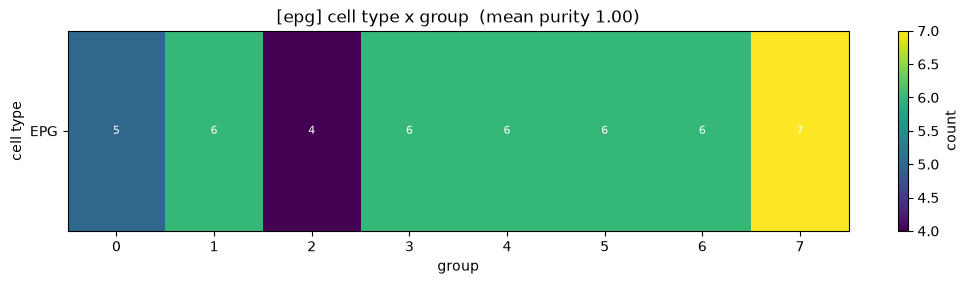

group      0  1  2  3  4  5  6  7
cell type                        
EPG        5  6  4  6  6  6  6  7


In [4]:
rc_epg = load_ring_connectome(['EPG'], reorder='spatial')
b_epg = explore_population(rc_epg, 'epg')

## Pass 2 — Delta7 + EPG combined

The full compass circuit (88 neurons). Spectral seriation ordering; the EPG ring
coordinate is retained where available (Delta7 has none).

[d7epg] n=88  k=8  groups=8  fidelity=3.9116
[d7epg] genuinely oscillatory slow modes (|Im|/|Re|>0.1): 0/8
saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_spectrum.pdf


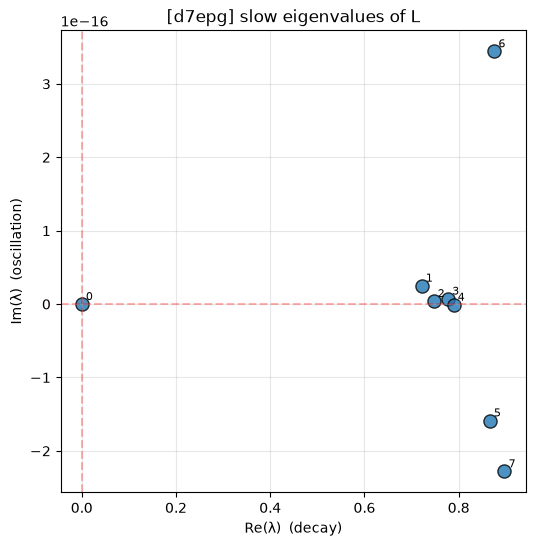

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_pairgrid.pdf


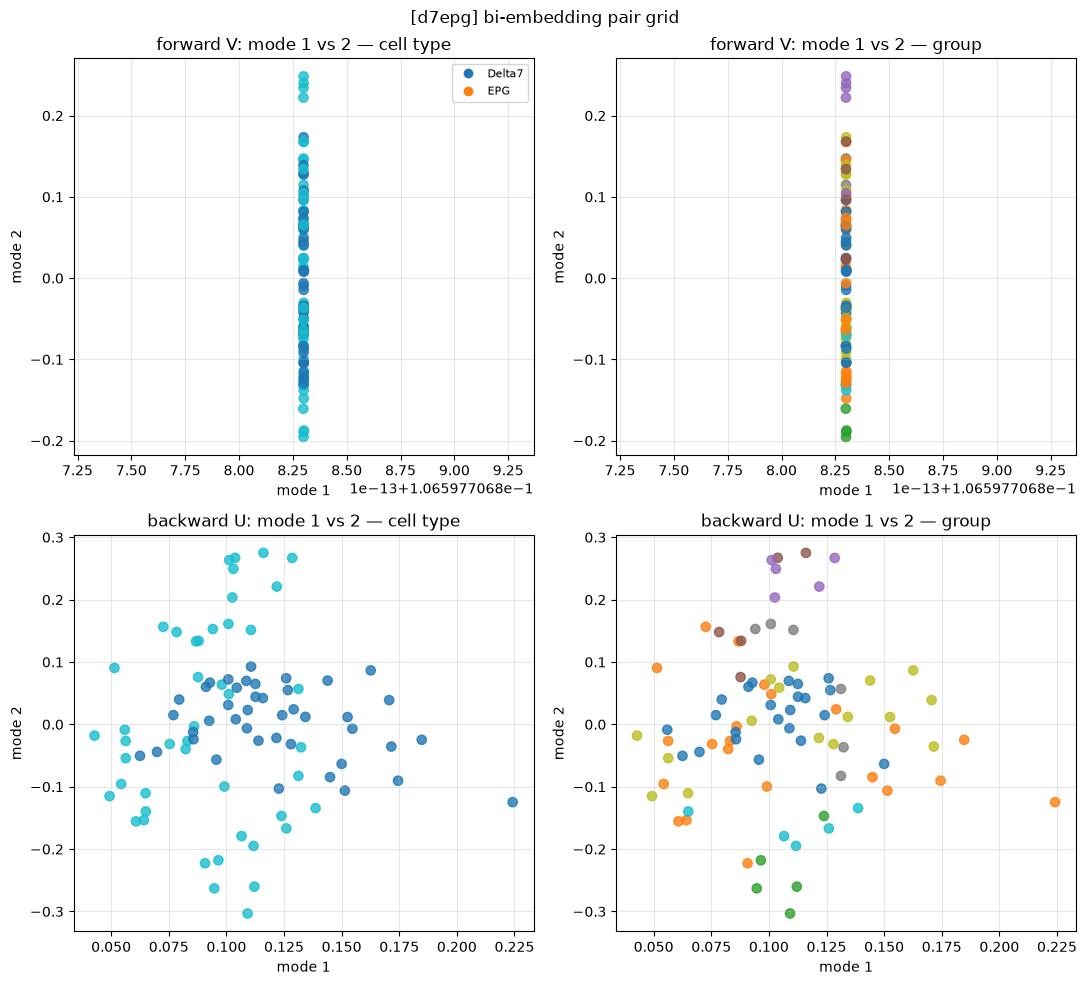

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_ring_manifold.pdf


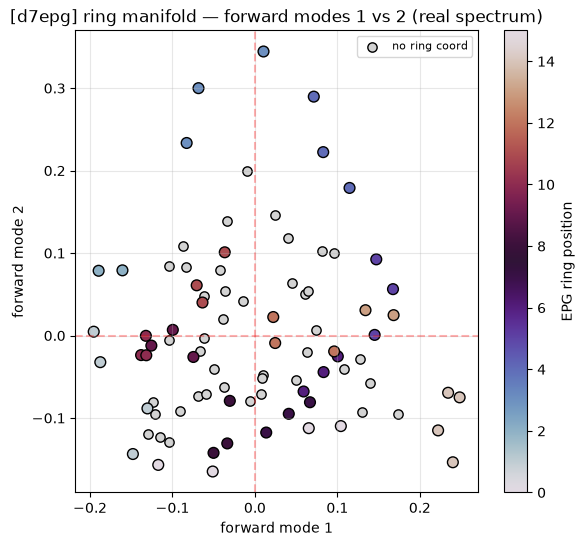

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_mode_profiles.pdf


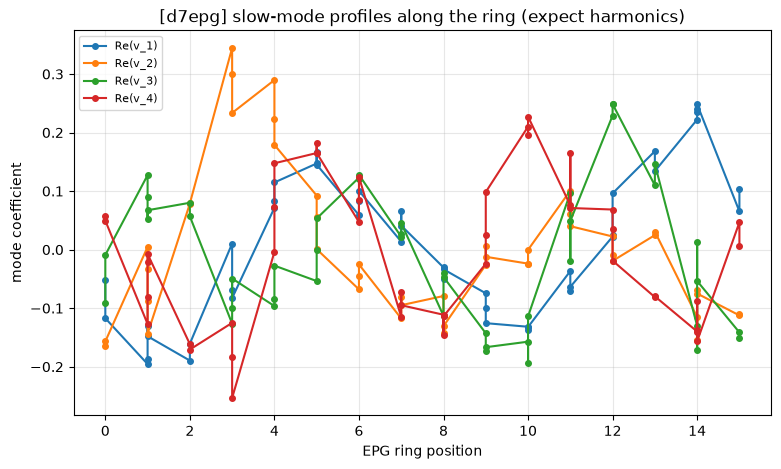

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_roles.pdf


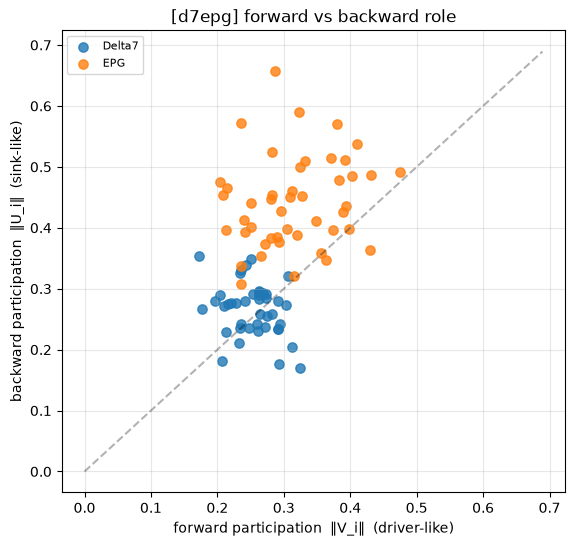

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_projection.pdf


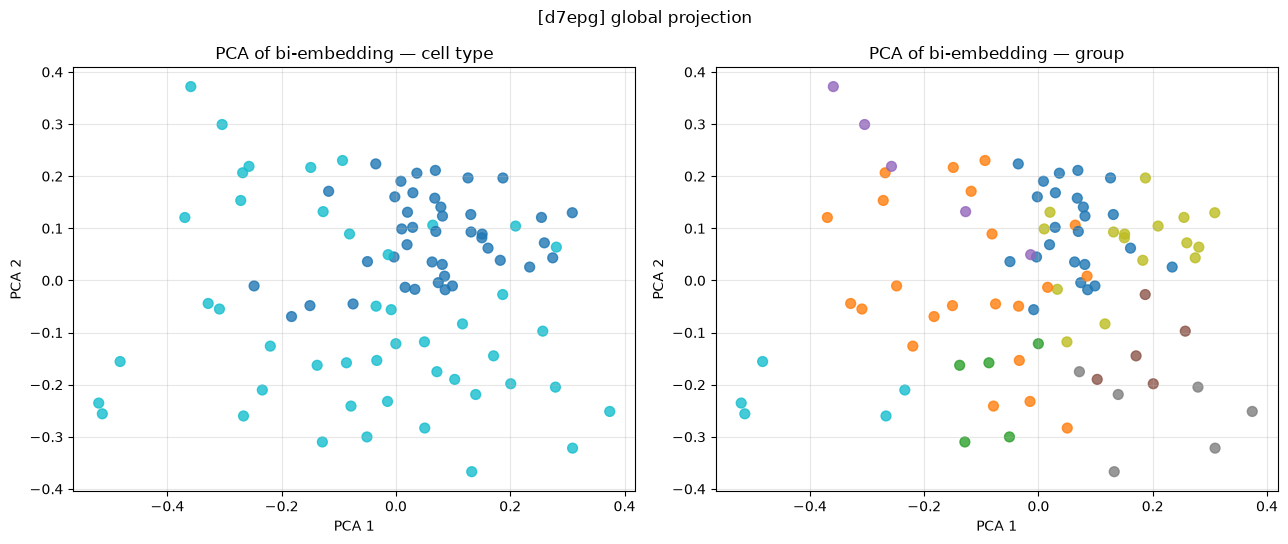

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_contingency.pdf


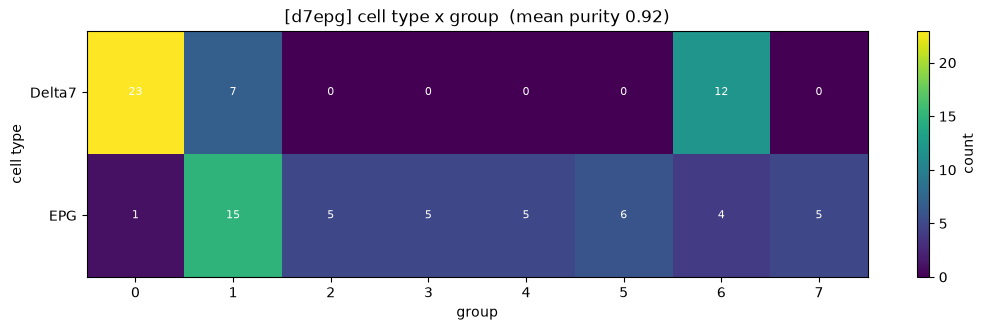

group       0   1  2  3  4  5   6  7
cell type                           
Delta7     23   7  0  0  0  0  12  0
EPG         1  15  5  5  5  6   4  5


In [5]:
rc_all = load_ring_connectome(['Delta7', 'EPG'], reorder='seriation')
b_all = explore_population(rc_all, 'd7epg')

### Cross-population: which slow modes does each cell type dominate?

Mean absolute forward-mode coefficient per slow mode, split by cell type — shows
whether the slow dynamics are carried more by EPG or Delta7.

saved /home/charlesxu/local/repo/MesoCompPrimitives/notebooks/../figures/biort_d7epg_mode_participation.pdf


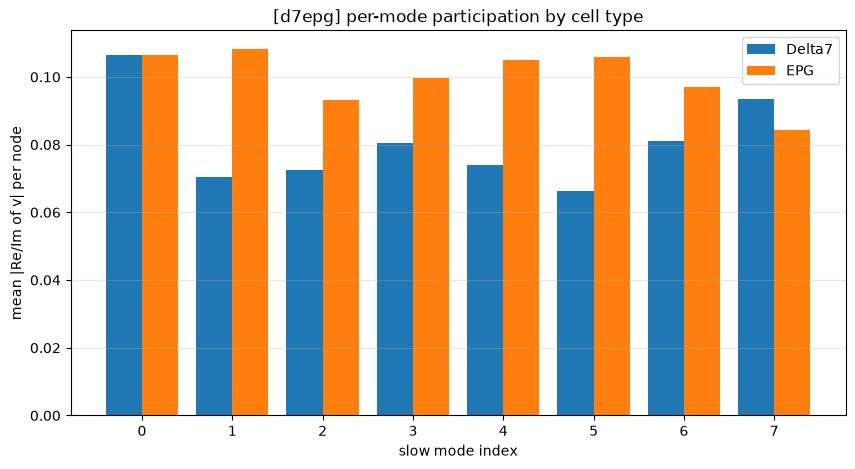

In [6]:
k = b_all['k']
ctoi = b_all['ctoi']; V = np.abs(b_all['V_c'])
types = sorted(set(ctoi.tolist()))
modes = np.arange(k)
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.8 / len(types)
for i, t in enumerate(types):
    msk = ctoi == t
    ax.bar(modes + i * w, V[msk].mean(axis=0), width=w, label=t)
ax.set_xlabel('slow mode index'); ax.set_ylabel('mean |Re/Im of v| per node')
ax.set_xticks(modes + w * (len(types) - 1) / 2); ax.set_xticklabels(modes)
ax.set_title('[d7epg] per-mode participation by cell type'); ax.legend(); ax.grid(alpha=.3, axis='y')
save_pdf(fig, 'biort_d7epg_mode_participation'); plt.show()